# Layerwise debug metrics analysis

Loads `debug_layerwise.jsonl` produced by `LayerwiseDebugTracker` and visualizes:

1. Global sanity scalars (global grad-norm reconstructed, logit norm/abs_max/entropy).
2. Per-role grad-norm trajectories (one line per layer, grouped by role).
3. Per-role weight-norm trajectories.
4. Trust-ratio heatmap (`grad_norm / weight_norm`) — the most load-bearing diagnostic.
5. Residual-stream RMS per block (if present).

Edit `JSONL_PATH` below to point at a different run.

In [58]:
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

JSONL_PATH = '/workspace/nanoplm/output/pretraining_checkpoints/run-24042309/debug_layerwise.jsonl'

records = []
with open(JSONL_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

print(f'Loaded {len(records)} log windows from {JSONL_PATH}')
print(f'Step range: {records[0]["step"]} → {records[-1]["step"]}')
print(f'Metrics per record: {len(records[0]["metrics"])}')

Loaded 56 log windows from /workspace/nanoplm/output/pretraining_checkpoints/run-24042309/debug_layerwise.jsonl
Step range: 10 → 560
Metrics per record: 219


In [59]:
# Unroll into a long dataframe: (step, metric_key, value)
rows = []
for rec in records:
    step = rec['step']
    for k, v in rec['metrics'].items():
        rows.append((step, k, v))
df = pd.DataFrame(rows, columns=['step', 'key', 'value'])

# Split key into kind / role / name
def parse_key(k):
    parts = k.split('/')
    # debug / kind / role / param_name  OR  debug / logits / {norm|abs_max|entropy}
    # OR debug / residual_rms / block_NNN
    if len(parts) < 3:
        return (parts[-1], '', '')
    kind = parts[1]
    if kind == 'logits':
        return ('logits', parts[2], '')
    if kind == 'residual_rms':
        return ('residual_rms', '', parts[2])
    # grad_norm / weight_norm : debug/kind/role/fullname
    role = parts[2]
    name = '/'.join(parts[3:])
    return (kind, role, name)

df[['kind', 'role', 'name']] = pd.DataFrame(df['key'].map(parse_key).tolist(), index=df.index)

# Extract layer index where applicable
layer_re = re.compile(r'layers\.(\d+)\.')
def layer_idx(n):
    m = layer_re.search(n)
    return int(m.group(1)) if m else -1
df['layer'] = df['name'].map(layer_idx)

print(df.head(8))
print('\nKinds:', df['kind'].value_counts().to_dict())
print('Roles:', df['role'].value_counts().to_dict())

   step                                                key       value  \
0    10  debug/grad_norm/embed/model.embeddings.tok_emb...    0.004370   
1    10  debug/weight_norm/embed/model.embeddings.tok_e...  156.603394   
2    10  debug/grad_norm/embed/model.embeddings.norm.we...    0.004339   
3    10  debug/weight_norm/embed/model.embeddings.norm....   27.712820   
4    10  debug/grad_norm/attn.q/model.layers.0.attn.Wq....    0.000054   
5    10  debug/weight_norm/attn.q/model.layers.0.attn.W...   27.696344   
6    10  debug/grad_norm/attn.k/model.layers.0.attn.Wk....    0.000056   
7    10  debug/weight_norm/attn.k/model.layers.0.attn.W...   27.726495   

          kind    role                                    name  layer  
0    grad_norm   embed  model.embeddings.tok_embeddings.weight     -1  
1  weight_norm   embed  model.embeddings.tok_embeddings.weight     -1  
2    grad_norm   embed            model.embeddings.norm.weight     -1  
3  weight_norm   embed            model.embed

## 1. Global sanity scalars

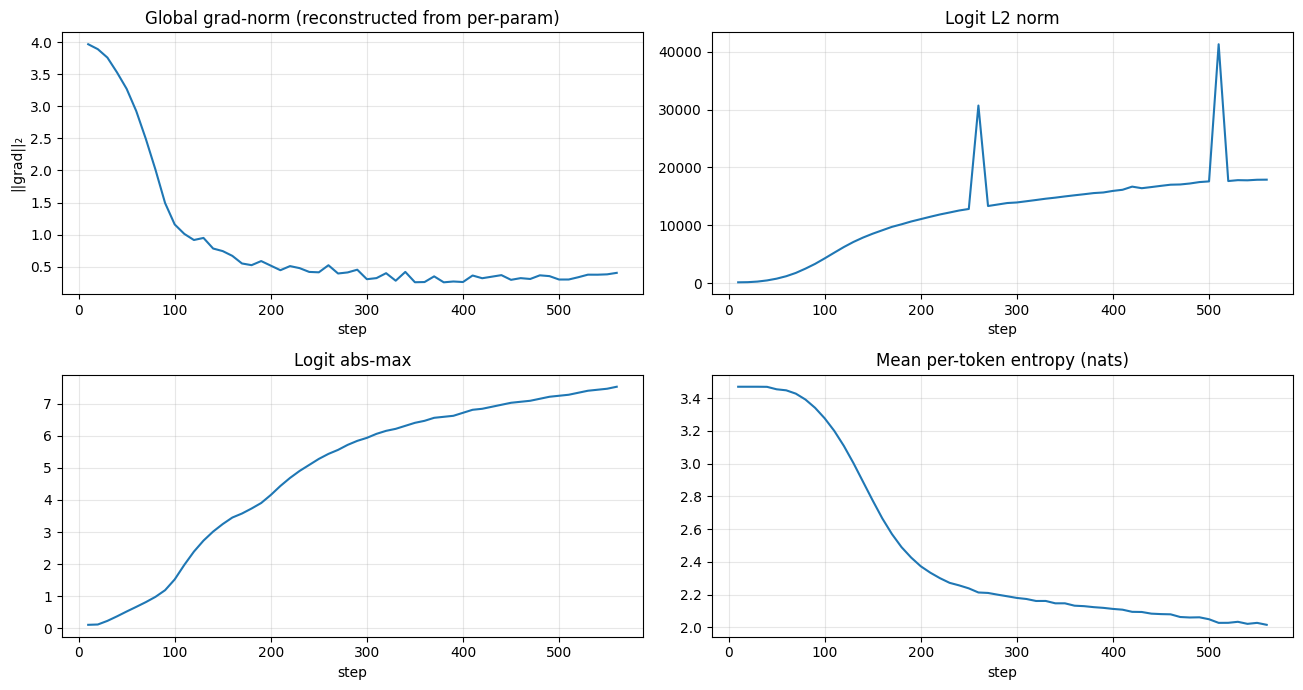

In [60]:
# Reconstruct a global grad-norm from per-param norms: sqrt(sum of squares).
gn = df[df['kind'] == 'grad_norm'].copy()
gn['sq'] = gn['value'] ** 2
global_gn = gn.groupby('step')['sq'].sum().pow(0.5).rename('global_grad_norm')

logits = df[df['kind'] == 'logits'].pivot(index='step', columns='role', values='value')

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0, 0].plot(global_gn.index, global_gn.values)
axes[0, 0].set_title('Global grad-norm (reconstructed from per-param)')
axes[0, 0].set_xlabel('step'); axes[0, 0].set_ylabel('||grad||₂'); axes[0, 0].grid(alpha=0.3)

if 'norm' in logits:
    axes[0, 1].plot(logits.index, logits['norm'])
    axes[0, 1].set_title('Logit L2 norm'); axes[0, 1].set_xlabel('step'); axes[0, 1].grid(alpha=0.3)
if 'abs_max' in logits:
    axes[1, 0].plot(logits.index, logits['abs_max'])
    axes[1, 0].set_title('Logit abs-max'); axes[1, 0].set_xlabel('step'); axes[1, 0].grid(alpha=0.3)
if 'entropy' in logits:
    axes[1, 1].plot(logits.index, logits['entropy'])
    axes[1, 1].set_title('Mean per-token entropy (nats)')
    axes[1, 1].set_xlabel('step'); axes[1, 1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Per-role grad-norm trajectories

One subplot per role. Within each role, one line per parameter, colored by layer index (viridis: dark=shallow, bright=deep). Non-layered params (embeddings, decoder, head) are overlaid in red.

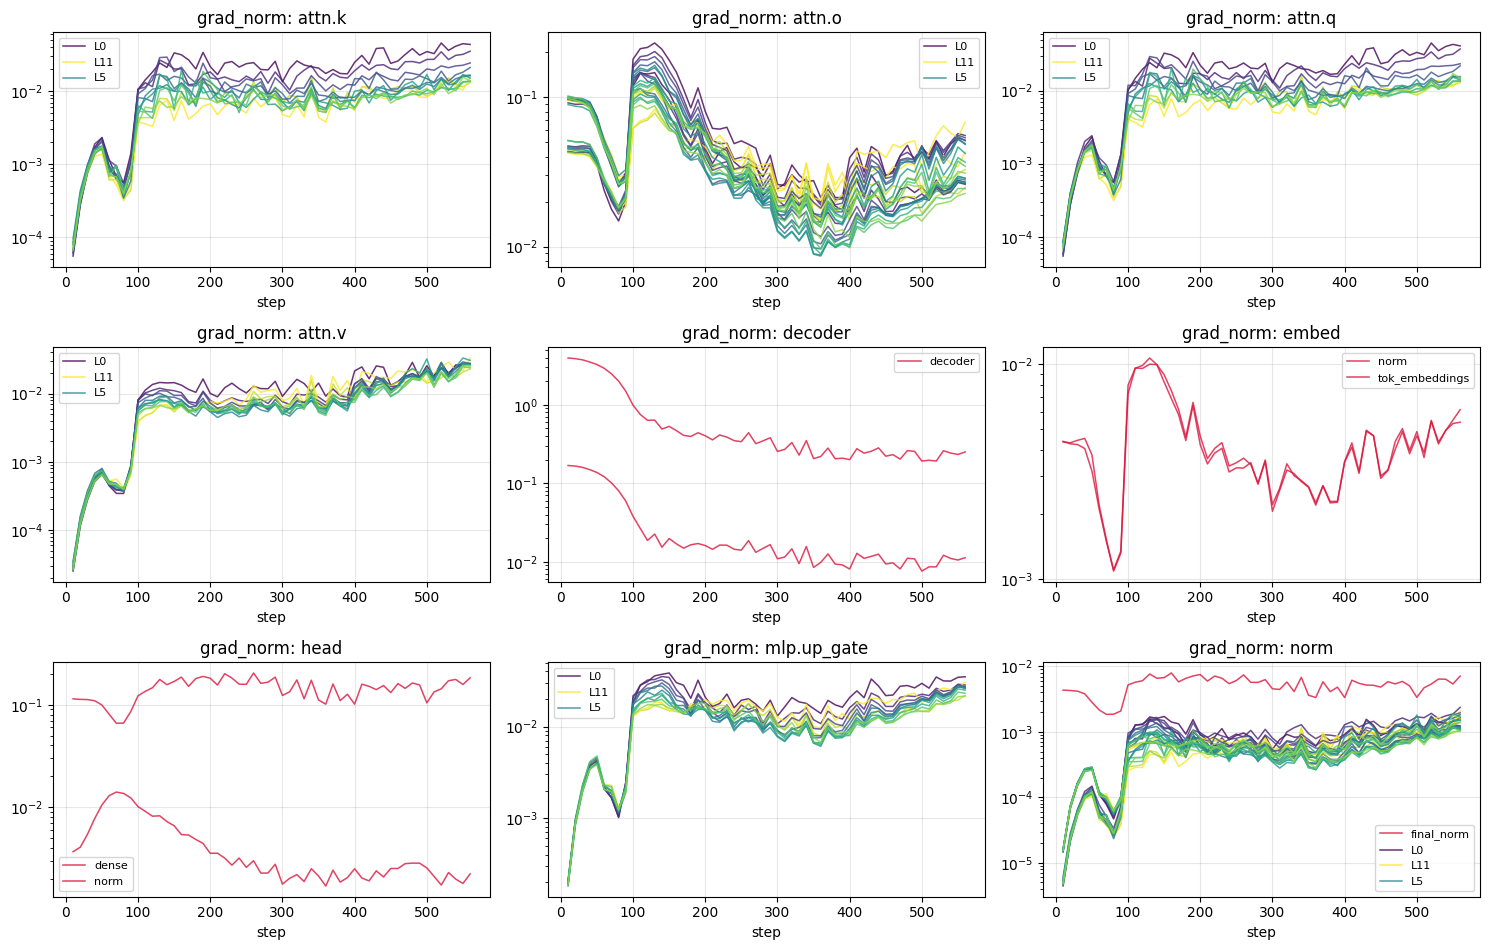

In [61]:
def trajectory_grid(kind, title, log=True):
    sub = df[df['kind'] == kind]
    roles = sorted(sub['role'].unique())
    n = len(roles)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.2 * rows), squeeze=False)
    axes = axes.ravel()
    max_layer = sub[sub['layer'] >= 0]['layer'].max()
    cmap = plt.cm.viridis
    for ax, role in zip(axes, roles):
        rsub = sub[sub['role'] == role]
        for name, g in rsub.groupby('name'):
            g = g.sort_values('step')
            li = g['layer'].iloc[0]
            if li >= 0 and max_layer is not None and max_layer > 0:
                color = cmap(li / max_layer)
                lbl = f'L{li}' if li in (0, max_layer // 2, max_layer) else None
            else:
                color = 'crimson'
                lbl = name.split('/')[-1].split('.')[-2] if '.' in name else name
            ax.plot(g['step'], g['value'], color=color, alpha=0.8, linewidth=1.1, label=lbl)
        ax.set_title(f'{title}: {role}')
        ax.set_xlabel('step'); ax.grid(alpha=0.3)
        if log:
            ax.set_yscale('log')
        # Dedupe legend
        h, l = ax.get_legend_handles_labels()
        seen = set(); hh, ll = [], []
        for hi, li2 in zip(h, l):
            if li2 and li2 not in seen:
                seen.add(li2); hh.append(hi); ll.append(li2)
        if ll:
            ax.legend(hh, ll, fontsize=8, loc='best')
    for ax in axes[len(roles):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

trajectory_grid('grad_norm', 'grad_norm', log=True)

## 3. Per-role weight-norm trajectories

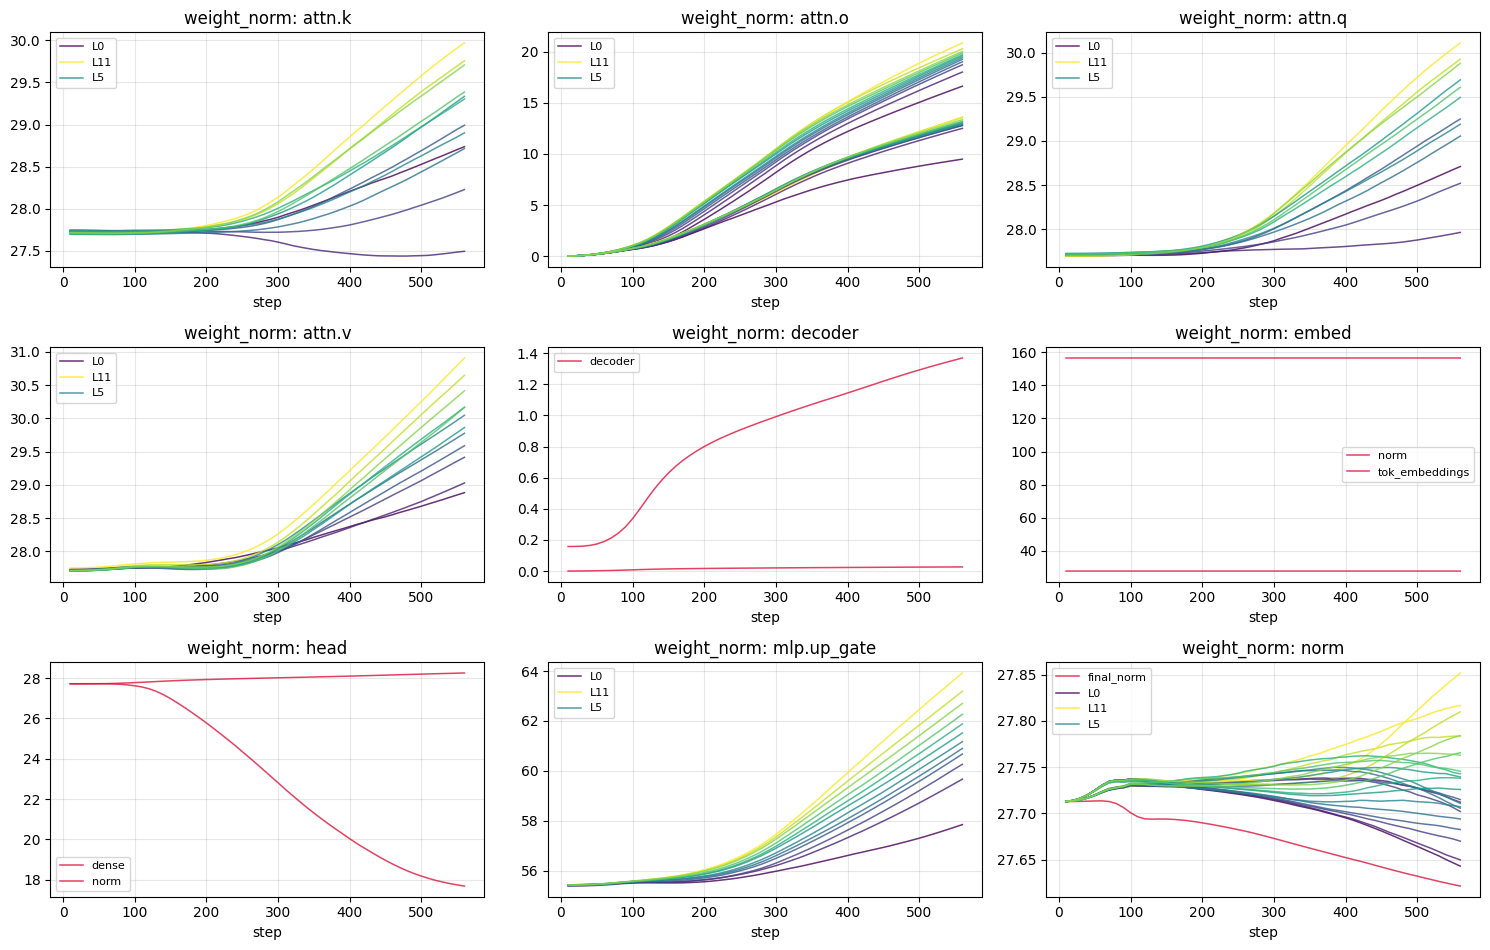

In [62]:
trajectory_grid('weight_norm', 'weight_norm', log=False)

## 4. Trust-ratio heatmap: `grad_norm / weight_norm` per layer

Adam-like optimizers produce effective updates proportional to `lr · grad_norm / weight_norm`. Healthy training keeps this in a narrow band across layers (commonly ~1e-3 to 1e-1 of LR). Outliers — rows that are orders of magnitude above/below the rest — are the layers to investigate.

One heatmap per role; rows = layer index, cols = step, color = log10(grad/weight).

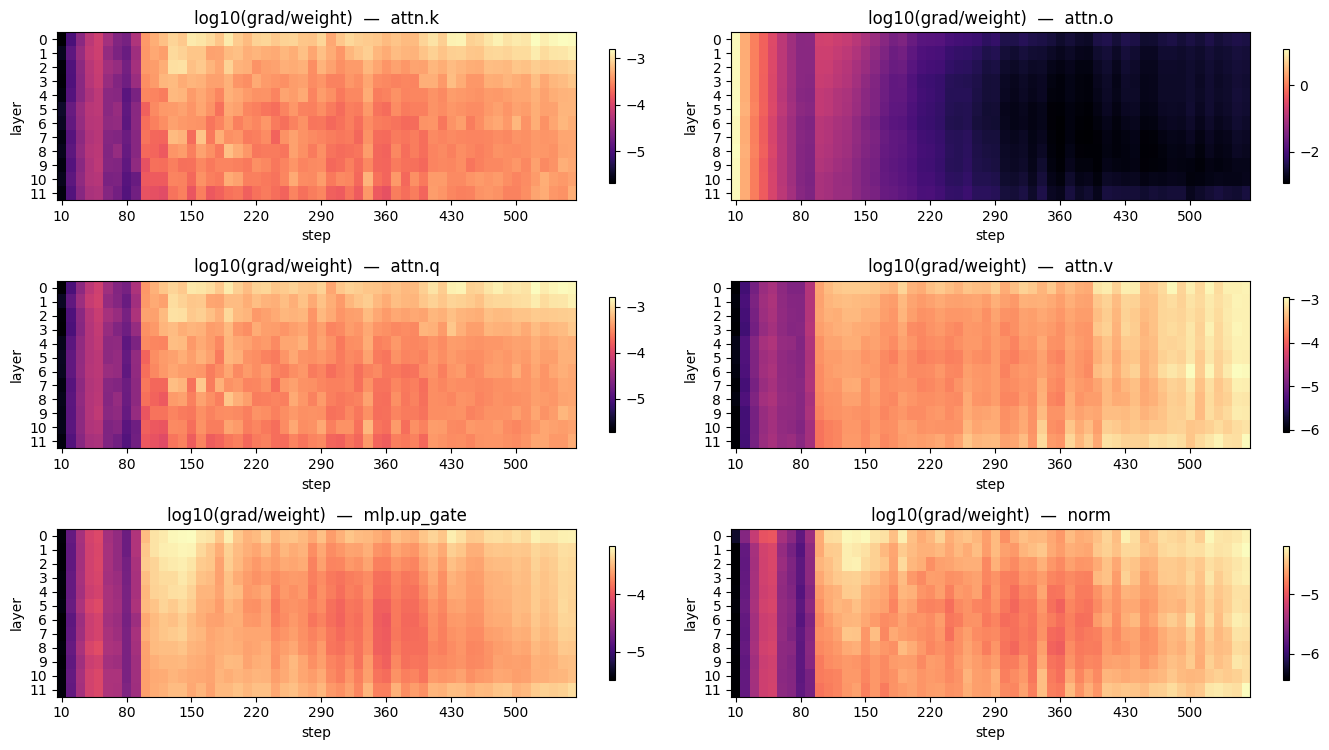

In [63]:
def ratio_heatmap(role_filter=None):
    gn = df[df['kind'] == 'grad_norm'][['step', 'role', 'name', 'layer', 'value']].rename(columns={'value': 'g'})
    wn = df[df['kind'] == 'weight_norm'][['step', 'role', 'name', 'layer', 'value']].rename(columns={'value': 'w'})
    merged = gn.merge(wn, on=['step', 'role', 'name', 'layer'])
    merged['ratio'] = merged['g'] / merged['w'].replace(0, np.nan)
    merged = merged[merged['layer'] >= 0]  # layered params only
    roles = sorted(merged['role'].unique())
    if role_filter:
        roles = [r for r in roles if r in role_filter]
    cols = 2
    rows = (len(roles) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 2.2 * rows + 1), squeeze=False)
    axes = axes.ravel()
    for ax, role in zip(axes, roles):
        rsub = merged[merged['role'] == role]
        pivot = rsub.pivot_table(index='layer', columns='step', values='ratio', aggfunc='mean')
        pivot = pivot.sort_index()
        with np.errstate(divide='ignore'):
            logv = np.log10(pivot.values)
        im = ax.imshow(logv, aspect='auto', cmap='magma', interpolation='nearest')
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        # sparse x-ticks
        xs = list(pivot.columns)
        step = max(1, len(xs) // 8)
        ax.set_xticks(range(0, len(xs), step))
        ax.set_xticklabels(xs[::step], rotation=0)
        ax.set_title(f'log10(grad/weight)  —  {role}')
        ax.set_xlabel('step'); ax.set_ylabel('layer')
        fig.colorbar(im, ax=ax, shrink=0.8)
    for ax in axes[len(roles):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

ratio_heatmap()

## 5. Residual-stream RMS per block

Shows how activation magnitude grows/shrinks with depth. Healthy pre-norm transformers show residual RMS growing slowly and smoothly with layer index; geometric growth is an early divergence signal.

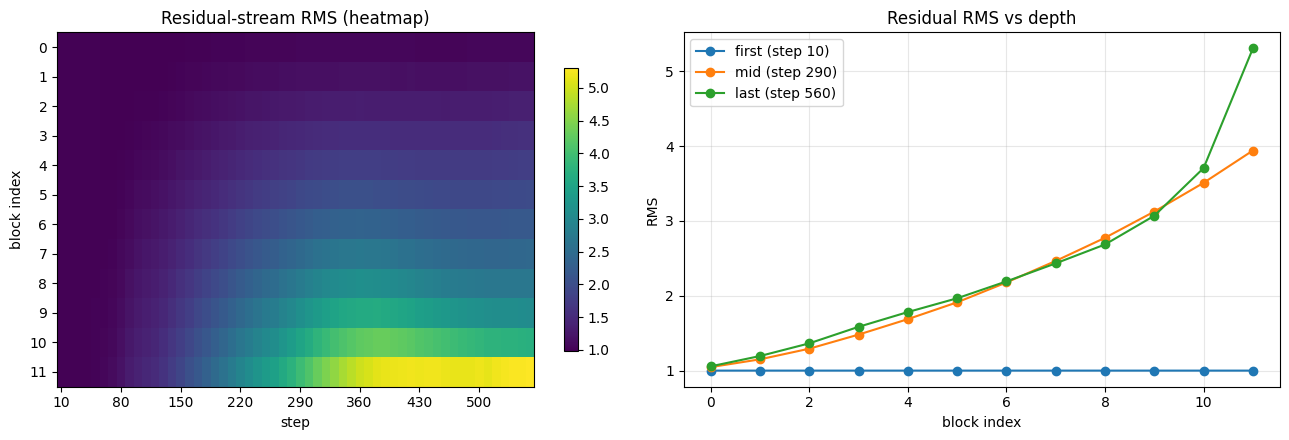

In [64]:
rr = df[df['kind'] == 'residual_rms']
if len(rr) == 0:
    print('No residual_rms keys in this run (no matching block classes, or hooks did not fire).')
else:
    rr = rr.copy()
    rr['block'] = rr['name'].str.extract(r'block_(\d+)').astype(int)
    pivot = rr.pivot_table(index='block', columns='step', values='value').sort_index()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    # Heatmap
    im = axes[0].imshow(pivot.values, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[0].set_title('Residual-stream RMS (heatmap)')
    axes[0].set_xlabel('step'); axes[0].set_ylabel('block index')
    axes[0].set_yticks(range(len(pivot.index))); axes[0].set_yticklabels(pivot.index)
    xs = list(pivot.columns); stp = max(1, len(xs) // 8)
    axes[0].set_xticks(range(0, len(xs), stp)); axes[0].set_xticklabels(xs[::stp])
    fig.colorbar(im, ax=axes[0], shrink=0.8)
    # Depth profile at first/mid/last step
    steps = list(pivot.columns)
    for s, lbl in [(steps[0], 'first'), (steps[len(steps)//2], 'mid'), (steps[-1], 'last')]:
        axes[1].plot(pivot.index, pivot[s].values, marker='o', label=f'{lbl} (step {s})')
    axes[1].set_title('Residual RMS vs depth')
    axes[1].set_xlabel('block index'); axes[1].set_ylabel('RMS')
    axes[1].grid(alpha=0.3); axes[1].legend()
    plt.tight_layout(); plt.show()

## 6. Summary table — final-step snapshot

In [66]:
last_step = df['step'].max()
snap = df[df['step'] == last_step].copy()

def summarize(kind):
    sub = snap[snap['kind'] == kind]
    if sub.empty:
        return pd.DataFrame()
    return sub.groupby('role')['value'].agg(['count', 'min', 'median', 'max'])

print(f'--- step {last_step} ---')
print('\ngrad_norm by role:')
print(summarize('grad_norm'))
print('\nweight_norm by role:')
print(summarize('weight_norm'))
logits_last = snap[snap['kind'] == 'logits'].set_index('role')['value']
print('\nlogits:')
print(logits_last)

--- step 560 ---

grad_norm by role:
             count       min    median       max
role                                            
attn.k          12  0.013121  0.015718  0.043563
attn.o          24  0.022650  0.031912  0.068319
attn.q          12  0.012891  0.014897  0.040975
attn.v          12  0.022941  0.026947  0.033132
decoder          2  0.011258  0.130790  0.250321
embed            2  0.005361  0.005747  0.006133
head             2  0.002232  0.092752  0.183271
mlp.up_gate     12  0.021583  0.026506  0.034976
norm            24  0.001020  0.001470  0.007116

weight_norm by role:
             count        min     median         max
role                                                
attn.k          12  27.491564  29.146738   29.969711
attn.o          24   9.492699  15.128543   20.864393
attn.q          12  27.964313  29.370846   30.109810
attn.v          12  28.881811  29.954367   30.909286
decoder          2   0.026664   0.697572    1.368480
embed            2  27.705162  